# 15 — Gleichstarke & stärkere Partien je Spielerin: Übersicht

Pro Spielerin der Top-40-Jahresende-Kohorte (2016–2025, siehe Notebook 14), über die ganze Karriere seit 2008: wie viele Partien insgesamt gegen ungefähr gleich starke Gegner (± 50 Elo, **Rating zum Zeitpunkt der jeweiligen Partie**), wie viele davon gegen Männer/Frauen, wie das direkte Ergebnis war (Siege/Remis/Niederlagen, Punktequote) und wie sich ihr Rating in diesen Partien im Schnitt verändert hat (`rating_change_weighted`). Zusätzlich: eine Jahres-Übersicht der Durchschnitts-Elo, und eine separate Auswertung für Partien gegen **mindestens 50 Elo stärkere** Gegner.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from _setup import load_query, apply_style

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

apply_style()
pd.set_option('display.max_rows', 100)

## Datenbasis laden

Drei Bausteine: (1) die volle Kohorte (auch Spielerinnen ohne jede Partie), (2) **alle** ihre Partien mit bekanntem eigenem und Gegner-Rating (keine Differenz-Einschränkung — die Buckets werden anschließend in Pandas gebildet).

In [2]:
sql_cohort = '''
WITH female_ranked AS (
    SELECT rh.fide_id,
           ROW_NUMBER() OVER (PARTITION BY rh.period ORDER BY rh.published_rating DESC) AS rnk
    FROM rating_history rh
    JOIN players p ON p.fide_id = rh.fide_id
    WHERE p.sex = 'F'
      AND rh.published_rating IS NOT NULL
      AND rh.period IN ('2016-12-01','2017-12-01','2018-12-01','2019-12-01','2020-12-01',
                        '2021-12-01','2022-12-01','2023-12-01','2024-12-01','2025-12-01')
),
female_cohort AS (
    SELECT DISTINCT fide_id FROM female_ranked WHERE rnk <= 40
)
SELECT fc.fide_id, p.name AS spielerin, p.active, p.std_rating AS aktuelles_rating
FROM female_cohort fc JOIN players p ON p.fide_id = fc.fide_id
'''
cohort = load_query(sql_cohort)
print(f'Kohorte: {len(cohort)} Spielerinnen')

sql_games = '''
WITH female_ranked AS (
    SELECT rh.fide_id,
           ROW_NUMBER() OVER (PARTITION BY rh.period ORDER BY rh.published_rating DESC) AS rnk
    FROM rating_history rh
    JOIN players p ON p.fide_id = rh.fide_id
    WHERE p.sex = 'F'
      AND rh.published_rating IS NOT NULL
      AND rh.period IN ('2016-12-01','2017-12-01','2018-12-01','2019-12-01','2020-12-01',
                        '2021-12-01','2022-12-01','2023-12-01','2024-12-01','2025-12-01')
),
female_cohort AS (
    SELECT DISTINCT fide_id FROM female_ranked WHERE rnk <= 40
)
SELECT
    gr.fide_id, gr.period, rh.std_rating AS own_rating, gr.opponent_rating,
    gr.opponent_sex, gr.result, gr.rating_change_weighted
FROM game_results gr
JOIN female_cohort fc        ON fc.fide_id = gr.fide_id
LEFT JOIN rating_history rh  ON rh.fide_id = gr.fide_id AND rh.period = gr.period
WHERE rh.std_rating IS NOT NULL
  AND gr.opponent_rating IS NOT NULL
'''
games = load_query(sql_games)
games['result'] = games['result'].astype(float)
games['rating_change_weighted'] = games['rating_change_weighted'].astype(float)
games['own_rating'] = pd.to_numeric(games['own_rating'], errors='coerce')
games['opponent_rating'] = pd.to_numeric(games['opponent_rating'], errors='coerce')
games['opponent_sex'] = games['opponent_sex'].fillna('unknown')
games['diff'] = games['opponent_rating'] - games['own_rating']
games['year'] = pd.to_datetime(games['period']).dt.year

equal = games[games['diff'].abs() <= 50].copy()
stronger = games[games['diff'] >= 50].copy()
print(f'Partien gesamt: {len(games):,}')
print(f'  davon ± 50 Elo ("gleich stark"): {len(equal):,}')
print(f'  davon Gegner ≥ 50 Elo stärker:   {len(stronger):,}')

Kohorte: 65 Spielerinnen


Partien gesamt: 55,973
  davon ± 50 Elo ("gleich stark"): 11,611
  davon Gegner ≥ 50 Elo stärker:   12,084


## Jahres-Übersicht — Durchschnitts-Elo der Gegner, je Gruppe

Ø-Rating **der Gegner** pro Jahr — getrennt für die beiden Paarungs-Gruppen (± 50 Elo "gleich stark" und ≥ 50 Elo "stärker"), nicht über alle Partien gemischt. Partie-gewichtet (jede Partie zählt einmal, unabhängig davon, wie oft eine bestimmte Gegnerin/ein bestimmter Gegner vorkommt).

In [3]:
def yearly_opponent_avg(df_bucket):
    return df_bucket.groupby('year').agg(
        n_partien=('opponent_rating', 'size'),
        oe_rating_gegner=('opponent_rating', 'mean'),
        oe_rating_gegner_vs_f=('opponent_rating', lambda s: s[df_bucket.loc[s.index, 'opponent_sex'] == 'F'].mean()),
        oe_rating_gegner_vs_m=('opponent_rating', lambda s: s[df_bucket.loc[s.index, 'opponent_sex'] == 'M'].mean()),
    ).round(1)

yearly_equal = yearly_opponent_avg(equal)
yearly_stronger = yearly_opponent_avg(stronger)

print('Gruppe: gleich stark (± 50 Elo)')
display(yearly_equal)
print('\nGruppe: stärkere Gegner (≥ 50 Elo)')
display(yearly_stronger)

Gruppe: gleich stark (± 50 Elo)


,n_partien,oe_rating_gegner,oe_rating_gegner_vs_f,oe_rating_gegner_vs_m
year,,,,
2008,519,2436.7,NaN,NaN
2009,729,2425.9,2428.0,2426.9
2010,636,2427.5,2425.9,2447.7
2011,788,2447.0,2453.7,2428.2
2012,702,2410.6,2416.5,2413.5
2013,747,2420.3,2430.5,2379.0
2014,637,2417.4,2422.6,2406.7
2015,696,2419.4,2425.3,2399.4
2016,693,2442.3,2444.3,2436.3



Gruppe: stärkere Gegner (≥ 50 Elo)


,n_partien,oe_rating_gegner,oe_rating_gegner_vs_f,oe_rating_gegner_vs_m
year,,,,
2008,573,2486.2,NaN,NaN
2009,842,2445.7,2391.1,2502.2
2010,783,2378.1,2334.1,2426.1
2011,859,2402.5,2414.6,2409.5
2012,873,2413.5,2395.5,2434.6
2013,994,2406.6,2388.4,2426.6
2014,765,2407.9,2350.5,2459.7
2015,783,2471.6,2427.9,2502.6
2016,839,2517.4,2450.7,2560.8


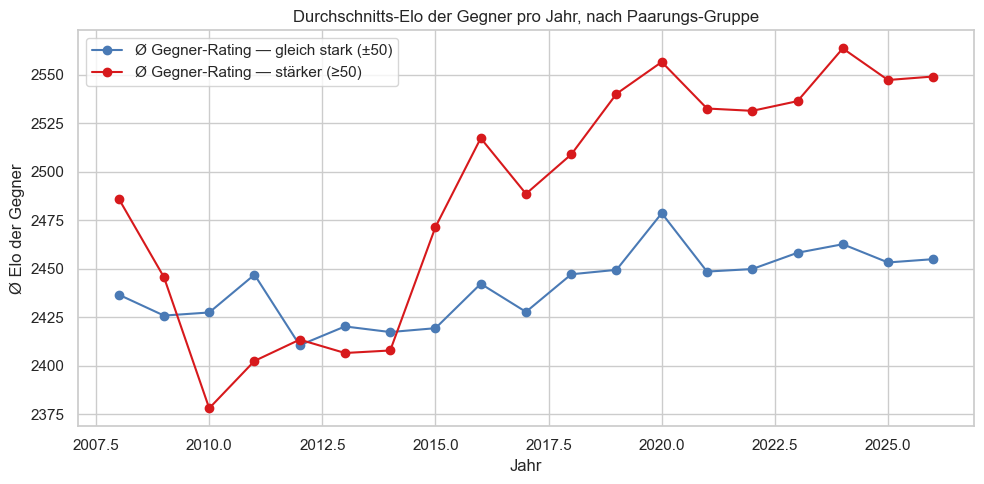

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_equal.index, yearly_equal['oe_rating_gegner'], marker='o', color='#4a7ab5', label='Ø Gegner-Rating — gleich stark (±50)')
ax.plot(yearly_stronger.index, yearly_stronger['oe_rating_gegner'], marker='o', color='#d7191c', label='Ø Gegner-Rating — stärker (≥50)')
ax.set_xlabel('Jahr')
ax.set_ylabel('Ø Elo der Gegner')
ax.set_title('Durchschnitts-Elo der Gegner pro Jahr, nach Paarungs-Gruppe')
ax.legend()
plt.tight_layout(); plt.show()

## Helper: Ergebnis-Kennzahlen je Teilmenge

Siege (`result==1`), Remis (`result==0.5`), Niederlagen (`result==0`), Punktequote (Ø `result`) und Ø/Σ `rating_change_weighted`.

In [5]:
def summarize(sub):
    n = len(sub)
    if n == 0:
        return pd.Series({
            'n_partien': 0, 'siege': 0, 'remis': 0, 'niederlagen': 0,
            'punktequote': np.nan, 'sum_delta': np.nan, 'mean_delta': np.nan,
        })
    return pd.Series({
        'n_partien': n,
        'siege': (sub['result'] == 1).sum(),
        'remis': (sub['result'] == 0.5).sum(),
        'niederlagen': (sub['result'] == 0).sum(),
        'punktequote': sub['result'].mean(),
        'sum_delta': sub['rating_change_weighted'].sum(),
        'mean_delta': sub['rating_change_weighted'].mean(),
    })

def per_player_summary(df_games):
    rows = []
    for fide_id, sub in df_games.groupby('fide_id'):
        row = {'fide_id': fide_id}
        row.update({f'{k}_gesamt': v for k, v in summarize(sub).items()})
        row.update({f'{k}_vs_f': v for k, v in summarize(sub[sub.opponent_sex == 'F']).items()})
        row.update({f'{k}_vs_m': v for k, v in summarize(sub[sub.opponent_sex == 'M']).items()})
        rows.append(row)
    return pd.DataFrame(rows)

## A. Gleich starke Gegner (± 50 Elo)

### Haupttabelle — eine Zeile pro Spielerin

Alle Spielerinnen der Kohorte; wer keine gescrapte Partie hat, erscheint mit 0/NaN.

In [6]:
summary_equal = per_player_summary(equal)
table_equal = cohort.merge(summary_equal, on='fide_id', how='left')
n_cols = [c for c in table_equal.columns if c.startswith('n_partien') or c.split('_gesamt')[0] in ('siege','remis','niederlagen')]
table_equal[n_cols] = table_equal[n_cols].fillna(0).astype(int)
table_equal = table_equal.sort_values('n_partien_gesamt', ascending=False).reset_index(drop=True)

display_cols = [
    'spielerin', 'active', 'aktuelles_rating',
    'n_partien_gesamt', 'n_partien_vs_f', 'n_partien_vs_m',
    'siege_gesamt', 'remis_gesamt', 'niederlagen_gesamt', 'punktequote_gesamt',
    'mean_delta_gesamt', 'sum_delta_gesamt',
]
table_equal[display_cols].round(3)

,spielerin,active,aktuelles_rating,n_partien_gesamt,n_partien_vs_f,n_partien_vs_m,siege_gesamt,remis_gesamt,niederlagen_gesamt,punktequote_gesamt,mean_delta_gesamt,sum_delta_gesamt
0,"Socko, Monika",True,2362,365,294,40,100,174,91,0.512,0.101,36.70
1,"Kashlinskaya, Alina",True,2480,352,287,41,109,148,95,0.520,0.223,78.50
2,"Tan, Zhongyi",True,2535,336,308,7,91,180,65,0.539,0.419,140.70
3,"Kosteniuk, Alexandra",True,2487,331,284,32,99,149,83,0.524,0.192,63.70
4,"Paehtz, Elisabeth",True,2403,318,238,60,61,185,72,0.483,-0.206,-65.60
5,"Girya, Olga",True,2380,318,256,20,96,144,78,0.528,0.247,78.65
6,"Gunina, Valentina",True,2393,312,263,15,105,94,113,0.487,-0.111,-34.55
7,"Dzagnidze, Nana",True,2478,308,279,6,86,149,73,0.521,0.061,18.70
8,"Dronavalli, Harika",True,2470,305,247,31,56,209,40,0.526,0.274,83.70
9,"Muzychuk, Anna",True,2522,296,231,30,52,205,39,0.522,0.100,29.70


### Detailtabelle — Ergebnis getrennt nach Gegner-Geschlecht

In [7]:
detail_cols = [
    'spielerin',
    'n_partien_vs_f', 'siege_vs_f', 'remis_vs_f', 'niederlagen_vs_f', 'punktequote_vs_f', 'mean_delta_vs_f',
    'n_partien_vs_m', 'siege_vs_m', 'remis_vs_m', 'niederlagen_vs_m', 'punktequote_vs_m', 'mean_delta_vs_m',
]
table_equal[detail_cols].round(3)

,spielerin,n_partien_vs_f,siege_vs_f,remis_vs_f,niederlagen_vs_f,punktequote_vs_f,mean_delta_vs_f,n_partien_vs_m,siege_vs_m,remis_vs_m,niederlagen_vs_m,punktequote_vs_m,mean_delta_vs_m
0,"Socko, Monika",294,81.0,140.0,73.0,0.514,0.112,40,12.0,16.0,12.0,0.500,0.040
1,"Kashlinskaya, Alina",287,90.0,130.0,67.0,0.540,0.471,41,11.0,13.0,17.0,0.427,-0.872
2,"Tan, Zhongyi",308,82.0,166.0,60.0,0.536,0.357,7,3.0,3.0,1.0,0.643,1.379
3,"Kosteniuk, Alexandra",284,86.0,125.0,73.0,0.523,0.150,32,7.0,17.0,8.0,0.484,-0.075
4,"Paehtz, Elisabeth",238,44.0,141.0,53.0,0.481,-0.216,60,12.0,33.0,15.0,0.475,-0.362
5,"Girya, Olga",256,77.0,115.0,64.0,0.525,0.217,20,6.0,8.0,6.0,0.500,-0.020
6,"Gunina, Valentina",263,92.0,77.0,94.0,0.496,-0.091,15,0.0,8.0,7.0,0.267,-2.387
7,"Dzagnidze, Nana",279,76.0,137.0,66.0,0.518,0.032,6,0.0,2.0,4.0,0.167,-2.883
8,"Dronavalli, Harika",247,49.0,170.0,28.0,0.543,0.414,31,3.0,21.0,7.0,0.435,-0.519
9,"Muzychuk, Anna",231,42.0,157.0,32.0,0.522,0.087,30,7.0,20.0,3.0,0.567,0.737


### Aggregat über alle Spielerinnen der Kohorte

Beantwortet die Ausgangsfrage in einer Zahl: über alle gleich starken Gegner hinweg — schneiden diese Top-Spielerinnen gegen Männer anders ab als gegen Frauen?

In [8]:
agg_equal = pd.DataFrame({
    'gesamt': summarize(equal),
    'vs Frauen': summarize(equal[equal.opponent_sex == 'F']),
    'vs Männer': summarize(equal[equal.opponent_sex == 'M']),
}).T
agg_equal[['n_partien','siege','remis','niederlagen']] = agg_equal[['n_partien','siege','remis','niederlagen']].astype(int)
agg_equal.round(4)

,n_partien,siege,remis,niederlagen,punktequote,sum_delta,mean_delta
gesamt,11611,3192,5791,2628,0.5243,3439.68,0.2962
vs Frauen,8892,2461,4459,1972,0.5275,2565.38,0.2885
vs Männer,1845,479,915,451,0.5076,585.40,0.3173


### Chart — Punktequote vs. Frauen vs. Punktequote vs. Männer, pro Spielerin

Jeder Punkt eine Spielerin (nur wenn sie ≥5 Partien in beiden Teilmengen hat, sonst zu verrauscht). Auf der Diagonalen: gleiche Punktequote gegen beide Geschlechter.

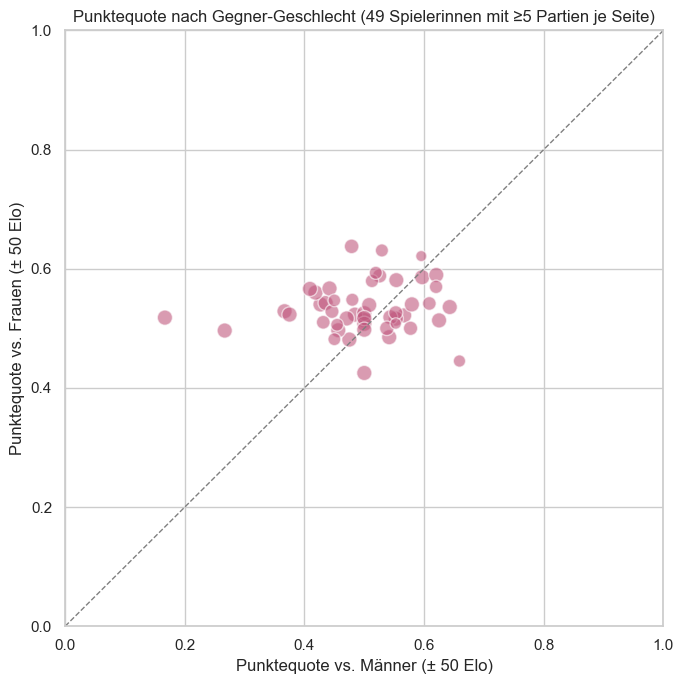

Besser (oder gleich) gegen Frauen: 31 von 49
Besser gegen Männer: 18 von 49


In [9]:
plot_df = table_equal[(table_equal.n_partien_vs_f >= 5) & (table_equal.n_partien_vs_m >= 5)].copy()
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(plot_df['punktequote_vs_m'], plot_df['punktequote_vs_f'],
           s=plot_df['n_partien_gesamt'].clip(upper=200) / 2 + 20,
           alpha=0.6, color='#c0587e', edgecolor='white')
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Punktequote vs. Männer (± 50 Elo)')
ax.set_ylabel('Punktequote vs. Frauen (± 50 Elo)')
ax.set_title(f'Punktequote nach Gegner-Geschlecht ({len(plot_df)} Spielerinnen mit ≥5 Partien je Seite)')
plt.tight_layout(); plt.show()

print(f'Besser (oder gleich) gegen Frauen: {(plot_df.punktequote_vs_f >= plot_df.punktequote_vs_m).sum()} von {len(plot_df)}')
print(f'Besser gegen Männer: {(plot_df.punktequote_vs_f < plot_df.punktequote_vs_m).sum()} von {len(plot_df)}')

## B. Stärkere Gegner (≥ 50 Elo mehr als die Spielerin)

Separate Auswertung: wie sieht das Ergebnis aus, wenn der Gegner/die Gegnerin mindestens 50 Elo-Punkte **stärker** ist als die Spielerin zum Zeitpunkt der Partie? Gleicher Tabellenaufbau wie oben, nur mit `diff >= 50` statt `|diff| <= 50`.

In [10]:
summary_stronger = per_player_summary(stronger)
table_stronger = cohort.merge(summary_stronger, on='fide_id', how='left')
n_cols = [c for c in table_stronger.columns if c.startswith('n_partien') or c.split('_gesamt')[0] in ('siege','remis','niederlagen')]
table_stronger[n_cols] = table_stronger[n_cols].fillna(0).astype(int)
table_stronger = table_stronger.sort_values('n_partien_gesamt', ascending=False).reset_index(drop=True)
table_stronger[display_cols].round(3)

,spielerin,active,aktuelles_rating,n_partien_gesamt,n_partien_vs_f,n_partien_vs_m,siege_gesamt,remis_gesamt,niederlagen_gesamt,punktequote_gesamt,mean_delta_gesamt,sum_delta_gesamt
0,"Vaishali, Rameshbabu",True,2470,648,155,473,125,188,335,0.338,1.170,758.45
1,Divya Deshmukh,True,2510,412,99,293,81,115,216,0.336,2.206,908.77
2,"Efroimski, Marsel",True,2386,404,78,271,72,152,180,0.366,1.176,475.25
3,"Goryachkina, Aleksandra",True,2534,389,116,262,57,183,149,0.382,1.063,413.35
4,"Saduakassova, Dinara",False,2435,382,88,277,58,154,170,0.353,1.080,412.75
5,"Khademalsharieh, Sarasadat",True,2414,374,144,212,68,158,148,0.393,1.758,657.55
6,"Assaubayeva, Bibisara",True,2516,363,113,236,70,123,170,0.362,2.311,838.95
7,"Mammadzada, Gunay",True,2374,342,158,140,80,97,165,0.376,1.938,662.90
8,"Kashlinskaya, Alina",True,2480,330,129,153,69,109,152,0.374,0.537,177.20
9,"Abdumalik, Zhansaya",False,2468,330,89,235,68,113,149,0.377,1.480,488.50


### Detailtabelle — stärkere Gegner, getrennt nach Geschlecht

In [11]:
table_stronger[detail_cols].round(3)

,spielerin,n_partien_vs_f,siege_vs_f,remis_vs_f,niederlagen_vs_f,punktequote_vs_f,mean_delta_vs_f,n_partien_vs_m,siege_vs_m,remis_vs_m,niederlagen_vs_m,punktequote_vs_m,mean_delta_vs_m
0,"Vaishali, Rameshbabu",155,29.0,54.0,72.0,0.361,0.614,473,92.0,127.0,254.0,0.329,1.389
1,Divya Deshmukh,99,26.0,27.0,46.0,0.399,4.579,293,49.0,80.0,164.0,0.304,1.235
2,"Efroimski, Marsel",78,6.0,37.0,35.0,0.314,-0.112,271,51.0,105.0,115.0,0.382,1.458
3,"Goryachkina, Aleksandra",116,24.0,47.0,45.0,0.409,1.422,262,31.0,132.0,99.0,0.370,0.869
4,"Saduakassova, Dinara",88,12.0,42.0,34.0,0.375,1.094,277,44.0,106.0,127.0,0.350,1.069
5,"Khademalsharieh, Sarasadat",144,34.0,60.0,50.0,0.444,1.923,212,30.0,88.0,94.0,0.349,1.364
6,"Assaubayeva, Bibisara",113,27.0,43.0,43.0,0.429,2.700,236,38.0,79.0,119.0,0.328,2.099
7,"Mammadzada, Gunay",158,44.0,46.0,68.0,0.424,2.607,140,27.0,42.0,71.0,0.343,1.382
8,"Kashlinskaya, Alina",129,27.0,56.0,46.0,0.426,0.779,153,29.0,43.0,81.0,0.330,0.229
9,"Abdumalik, Zhansaya",89,19.0,36.0,34.0,0.416,1.946,235,47.0,76.0,112.0,0.362,1.277


### Aggregat — stärkere Gegner (≥ 50 Elo)

In [12]:
agg_stronger = pd.DataFrame({
    'gesamt': summarize(stronger),
    'vs Frauen': summarize(stronger[stronger.opponent_sex == 'F']),
    'vs Männer': summarize(stronger[stronger.opponent_sex == 'M']),
}).T
agg_stronger[['n_partien','siege','remis','niederlagen']] = agg_stronger[['n_partien','siege','remis','niederlagen']].astype(int)
agg_stronger.round(4)

,n_partien,siege,remis,niederlagen,punktequote,sum_delta,mean_delta
gesamt,12084,2035,4894,5155,0.3709,12427.44,1.0284
vs Frauen,4514,843,1991,1680,0.4073,5559.96,1.2317
vs Männer,6638,1011,2568,3059,0.3457,6110.43,0.9205


### Vergleich: gleich stark vs. stärkere Gegner (Aggregat nebeneinander)

In [13]:
compare = pd.concat({'gleich stark (±50)': agg_equal, 'stärkere Gegner (≥50)': agg_stronger}, axis=0)
compare.round(4)

n_partien  siege  remis  niederlagen  \
gleich stark (±50)    gesamt         11611   3192   5791         2628   
                      vs Frauen       8892   2461   4459         1972   
                      vs Männer       1845    479    915          451   
stärkere Gegner (≥50) gesamt         12084   2035   4894         5155   
                      vs Frauen       4514    843   1991         1680   
                      vs Männer       6638   1011   2568         3059   

                                 punktequote  sum_delta  mean_delta  
gleich stark (±50)    gesamt          0.5243    3439.68      0.2962  
                      vs Frauen       0.5275    2565.38      0.2885  
                      vs Männer       0.5076     585.40      0.3173  
stärkere Gegner (≥50) gesamt          0.3709   12427.44      1.0284  
                      vs Frauen       0.4073    5559.96      1.2317  
                      vs Männer       0.3457    6110.43      0.9205

## Export

In [14]:
table_equal.to_csv('top40_equal_strength_summary_per_player.csv', index=False)
table_stronger.to_csv('top40_stronger_opponent_summary_per_player.csv', index=False)
yearly_equal.to_csv('top40_yearly_avg_opponent_rating_equal.csv')
yearly_stronger.to_csv('top40_yearly_avg_opponent_rating_stronger.csv')
print('wrote top40_equal_strength_summary_per_player.csv, top40_stronger_opponent_summary_per_player.csv, '
      'top40_yearly_avg_opponent_rating_equal.csv, top40_yearly_avg_opponent_rating_stronger.csv')

wrote top40_equal_strength_summary_per_player.csv, top40_stronger_opponent_summary_per_player.csv, top40_yearly_avg_opponent_rating_equal.csv, top40_yearly_avg_opponent_rating_stronger.csv
